In [ ]:
import os,certifi
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
load_dotenv()

C:\Users\kumar\AppData\Local\Temp\ipykernel_25292\3561067337.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


True

In [7]:
!pip install langgraph

In [ ]:
from langchain.agents import create_agent

In [3]:
os.environ["SSL_CERT_FILE"] = certifi.where()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [4]:
search_tool=TavilySearchResults(max_results=2)

C:\Users\kumar\AppData\Local\Temp\ipykernel_25292\3555774140.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool=TavilySearchResults(max_results=2)


In [5]:
search_tool.invoke("how cool is clint eastwood?")

[{'title': 'All Clint Eastwood Movies Ranked\t\t\t\t\t\t\t | \tRotten Tomatoes',
  'url': 'https://editorial.rottentomatoes.com/guide/all-clint-eastwood-movies-ranked',
  'content': 'Directed By: \nClint Eastwood\n\n  \n\n#22\n\n\nTomatometer icon\n86%\n\nCritics Consensus: No consensus yet.\n\nSynopsis: A New Orleans police detective (Clint Eastwood) finds he has some of the same traits as a serial killer of prostitutes.\n\nStarring: \nClint Eastwood, Geneviève Bujold, Dan Hedaya, Alison Eastwood\n\nDirected By: \nRichard Tuggle\n\n  \n\n#23\n\n\nTomatometer icon\n85%\n\nCritics Consensus: A coolly calculating psychological thriller that manages to scare the audience even if it is just using textbook thrills.\n\nSynopsis: Popular radio show host Dave Garver becomes restless in his relationship with his girlfriend. Impulsively, he goes out and sleeps with a woman he meets... View Full Synopsis\n\nStarring: \nClint Eastwood, Jessica Walter, Donna Mills, John Larch\n\nDirected By: \nClin

In [6]:
llm=ChatOpenAI(model=os.getenv("MODEL_NAME"),temperature=0,openai_api_key=OPENAI_API_KEY)

In [8]:
llm.invoke("who is cooler between clint eastwood, sean connery, and bruce willis?")

AIMessage(content='That’s a tough call! All three are icons, but their “coolness” comes from different vibes:\n\n- **Clint Eastwood**: The epitome of the stoic, tough-as-nails cowboy and cop. His “Man with No Name” and “Dirty Harry” roles basically *define* cinematic cool for many people. He’s got that squint, the gravelly voice, and a legendary career as both actor and director.\n\n- **Sean Connery**: The original James Bond. Suave, witty, and effortlessly charming, Connery set the standard for cool spies everywhere. He also brought gravitas to roles in films like *The Untouchables* and *Indiana Jones and the Last Crusade*.\n\n- **Bruce Willis**: The everyman action hero. As John McClane in *Die Hard*, he made vulnerability and sarcasm cool, and he’s got a knack for mixing humor with badassery.\n\n**Who’s cooler?**  \nIt depends on your flavor of cool:\n- If you like stoic, silent, and intimidating: **Clint Eastwood**.\n- If you prefer suave, witty, and sophisticated: **Sean Connery**

In [9]:
tools=[search_tool]

In [10]:
from langchain_core.prompts import ChatPromptTemplate

In [14]:
prompt="""You are a helpful assistant that can use tools.

Think step by step.
Use tools whenever necessary.
After observing tool results, provide the final answer.
"""

In [16]:
agent=create_agent(model=llm,tools=tools,system_prompt=prompt)

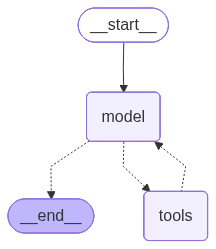

In [17]:
agent

In [ ]:
A

In [29]:
response=agent.invoke({
    "messages":[("user","how cool is clint eastwood?")]
})

In [31]:
response["messages"][-1].content

'Clint Eastwood is widely regarded as one of the coolest figures in American pop culture. He was even named the "Coolest Man in America," beating out celebrities like President Obama, George Clooney, and Justin Timberlake. His iconic roles in films, calm demeanor, and legendary status in Hollywood have contributed to his reputation for coolness. Even critics who were tough on his movies often praised his "cool, cinematic grace." So, Clint Eastwood is considered extremely cool by both fans and critics alike!'